In [1]:
# Install packages not pre-installed on Colab
!pip install shap xgboost --quiet

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("ranzeet013/migraine-dataset")
print("Path to dataset files:", path)

# See what files are actually in that folder
print("\nFiles downloaded:", os.listdir(path))

100%|██████████| 2.93k/2.93k [00:00<00:00, 4.34MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ranzeet013/migraine-dataset/versions/1

Files downloaded: ['migraine_data.csv']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Construct the full path to the CSV
# Replace 'migraine.csv' with whatever os.listdir showed you
csv_path = os.path.join(path, 'migraine_data.csv')
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())
print("\nTarget variable distribution:")
print(df['Type'].value_counts())
print("\nMissing values per column:")
print(df.isnull().sum())

Shape: (400, 24)

Columns: ['Age', 'Duration', 'Frequency', 'Location', 'Character', 'Intensity', 'Nausea', 'Vomit', 'Phonophobia', 'Photophobia', 'Visual', 'Sensory', 'Dysphasia', 'Dysarthria', 'Vertigo', 'Tinnitus', 'Hypoacusis', 'Diplopia', 'Defect', 'Ataxia', 'Conscience', 'Paresthesia', 'DPF', 'Type']

First 5 rows:


,Age,Duration,Frequency,Location,Character,Intensity,Nausea,Vomit,Phonophobia,Photophobia,...,Vertigo,Tinnitus,Hypoacusis,Diplopia,Defect,Ataxia,Conscience,Paresthesia,DPF,Type
0,30,1,5,1,1,2,1,0,1,1,...,0,0,0,0,0,0,0,0,0,Typical aura with migraine
1,50,3,5,1,1,3,1,1,1,1,...,1,0,0,0,0,0,0,0,0,Typical aura with migraine
2,53,2,1,1,1,2,1,1,1,1,...,0,0,0,0,0,0,0,0,0,Typical aura with migraine
3,45,3,5,1,1,3,1,0,1,1,...,1,0,0,0,0,0,0,0,0,Typical aura with migraine
4,53,1,1,1,1,2,1,0,1,1,...,0,0,0,0,0,0,0,0,1,Typical aura with migraine



Target variable distribution:
Type
Typical aura with migraine       247
Migraine without aura             60
Familial hemiplegic migraine      24
Typical aura without migraine     20
Basilar-type aura                 18
Other                             17
Sporadic hemiplegic migraine      14
Name: count, dtype: int64

Missing values per column:
Age            0
Duration       0
Frequency      0
Location       0
Character      0
Intensity      0
Nausea         0
Vomit          0
Phonophobia    0
Photophobia    0
Visual         0
Sensory        0
Dysphasia      0
Dysarthria     0
Vertigo        0
Tinnitus       0
Hypoacusis     0
Diplopia       0
Defect         0
Ataxia         0
Conscience     0
Paresthesia    0
DPF            0
Type           0
dtype: int64


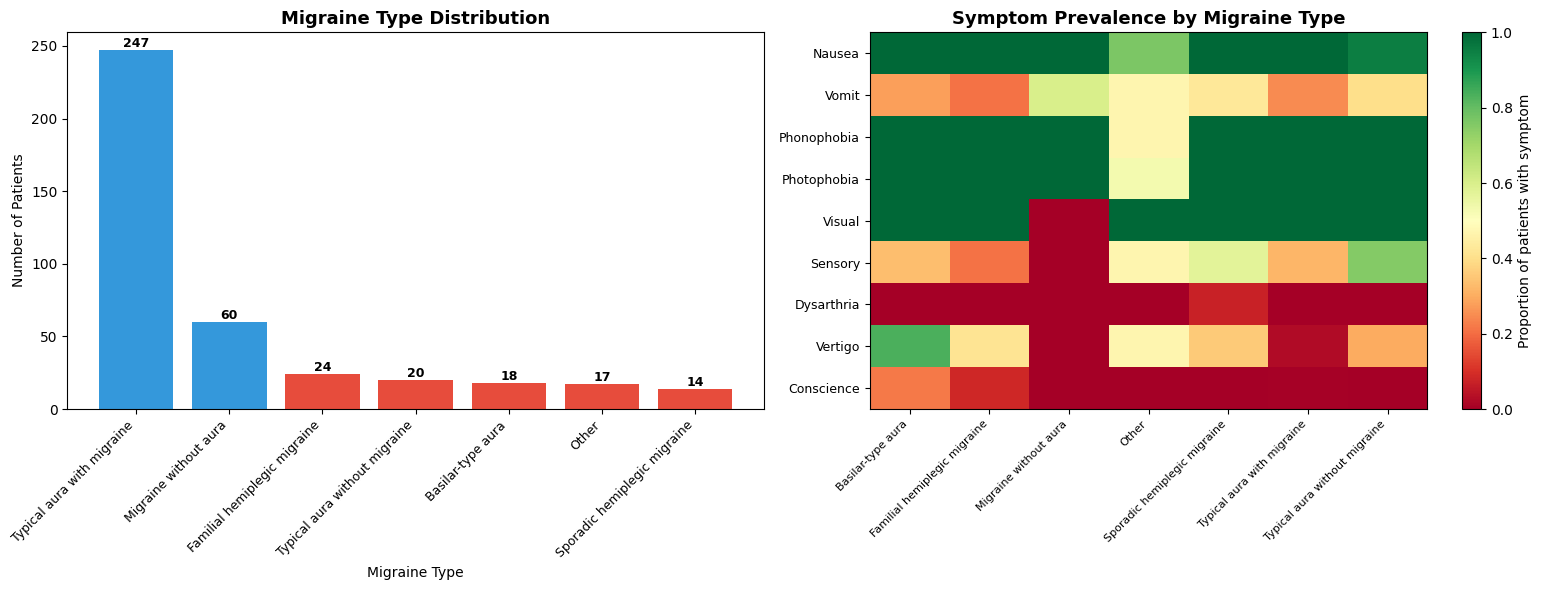

In [4]:
import os
os.makedirs('figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: class distribution
type_counts = df['Type'].value_counts()
colors = ['#e74c3c' if count < 30 else '#3498db' for count in type_counts.values]

axes[0].bar(range(len(type_counts)), type_counts.values, color=colors)
axes[0].set_xticks(range(len(type_counts)))
axes[0].set_xticklabels(type_counts.index, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Migraine Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xlabel('Migraine Type')

for i, (count, label) in enumerate(zip(type_counts.values, type_counts.index)):
    axes[0].text(i, count + 2, str(count), ha='center', fontsize=9, fontweight='bold')

# Right plot: symptom heatmap by migraine type
symptom_cols = ['Nausea', 'Vomit', 'Phonophobia', 'Photophobia',
                'Visual', 'Sensory', 'Dysarthria', 'Vertigo', 'Conscience']

symptom_means = df.groupby('Type')[symptom_cols].mean()

im = axes[1].imshow(symptom_means.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_xticks(range(len(symptom_means.index)))
axes[1].set_xticklabels(symptom_means.index, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks(range(len(symptom_cols)))
axes[1].set_yticklabels(symptom_cols, fontsize=9)
axes[1].set_title('Symptom Prevalence by Migraine Type', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=axes[1], label='Proportion of patients with symptom')

plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Type', axis=1)
y = df['Type']

# Encode target labels as integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label encoding mapping:")
for i, class_name in enumerate(le.classes_):
    print(f"  {i}: {class_name}")

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nClass distribution in training set:")
train_dist = pd.Series(y_train).value_counts().sort_index()
for idx, count in train_dist.items():
    print(f"  {le.classes_[idx]}: {count}")

print(f"\nClass distribution in test set:")
test_dist = pd.Series(y_test).value_counts().sort_index()
for idx, count in test_dist.items():
    print(f"  {le.classes_[idx]}: {count}")

Label encoding mapping:
  0: Basilar-type aura
  1: Familial hemiplegic migraine
  2: Migraine without aura
  3: Other
  4: Sporadic hemiplegic migraine
  5: Typical aura with migraine
  6: Typical aura without migraine

Training set: 320 samples
Test set: 80 samples

Class distribution in training set:
  Basilar-type aura: 14
  Familial hemiplegic migraine: 19
  Migraine without aura: 48
  Other: 14
  Sporadic hemiplegic migraine: 11
  Typical aura with migraine: 198
  Typical aura without migraine: 16

Class distribution in test set:
  Basilar-type aura: 4
  Familial hemiplegic migraine: 5
  Migraine without aura: 12
  Other: 3
  Sporadic hemiplegic migraine: 3
  Typical aura with migraine: 49
  Typical aura without migraine: 4


RANDOM FOREST RESULTS
                               precision    recall  f1-score   support

            Basilar-type aura       0.50      0.25      0.33         4
 Familial hemiplegic migraine       0.45      1.00      0.62         5
        Migraine without aura       0.86      1.00      0.92        12
                        Other       1.00      0.67      0.80         3
 Sporadic hemiplegic migraine       1.00      0.67      0.80         3
   Typical aura with migraine       0.98      0.90      0.94        49
Typical aura without migraine       1.00      1.00      1.00         4

                     accuracy                           0.88        80
                    macro avg       0.83      0.78      0.77        80
                 weighted avg       0.91      0.88      0.88        80



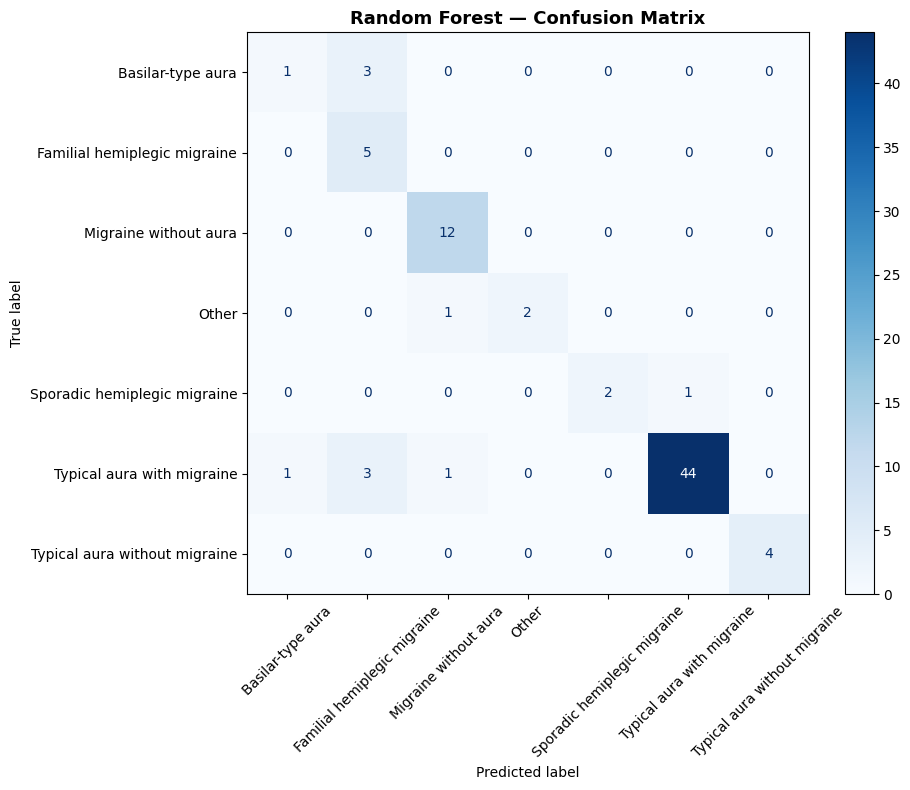


Accuracy: 0.8750
Macro F1 Score: 0.7739


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Define model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Classification report
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Primary metric
report_dict = classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)
macro_f1 = report_dict['macro avg']['f1-score']
accuracy = report_dict['accuracy']
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")

In [7]:
from xgboost import XGBClassifier
import numpy as np

# Compute sample weights manually for XGBoost
class_counts = np.bincount(y_train)
total = len(y_train)
n_classes = len(class_counts)
sample_weights = np.array([total / (n_classes * class_counts[y]) for y in y_train])

# Define and train model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)

print("XGBOOST RESULTS")
print("=" * 50)
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=le.classes_,
    zero_division=0
))

report_xgb = classification_report(
    y_test, y_pred_xgb,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)
print(f"Accuracy: {report_xgb['accuracy']:.4f}")
print(f"Macro F1: {report_xgb['macro avg']['f1-score']:.4f}")

XGBOOST RESULTS
                               precision    recall  f1-score   support

            Basilar-type aura       0.67      0.50      0.57         4
 Familial hemiplegic migraine       0.57      0.80      0.67         5
        Migraine without aura       0.86      1.00      0.92        12
                        Other       1.00      0.67      0.80         3
 Sporadic hemiplegic migraine       1.00      0.67      0.80         3
   Typical aura with migraine       0.96      0.94      0.95        49
Typical aura without migraine       1.00      1.00      1.00         4

                     accuracy                           0.90        80
                    macro avg       0.86      0.80      0.82        80
                 weighted avg       0.91      0.90      0.90        80

Accuracy: 0.9000
Macro F1: 0.8157


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=le.classes_, zero_division=0))
report_lr = classification_report(y_test, y_pred_lr, target_names=le.classes_, output_dict=True, zero_division=0)
print(f"Accuracy: {report_lr['accuracy']:.4f}")
print(f"Macro F1: {report_lr['macro avg']['f1-score']:.4f}")

print("\n")

# SVM
svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42,
    probability=True
)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM RESULTS")
print("=" * 50)
print(classification_report(y_test, y_pred_svm, target_names=le.classes_, zero_division=0))
report_svm = classification_report(y_test, y_pred_svm, target_names=le.classes_, output_dict=True, zero_division=0)
print(f"Accuracy: {report_svm['accuracy']:.4f}")
print(f"Macro F1: {report_svm['macro avg']['f1-score']:.4f}")

LOGISTIC REGRESSION RESULTS
                               precision    recall  f1-score   support

            Basilar-type aura       1.00      0.75      0.86         4
 Familial hemiplegic migraine       0.29      1.00      0.45         5
        Migraine without aura       0.86      1.00      0.92        12
                        Other       1.00      0.67      0.80         3
 Sporadic hemiplegic migraine       0.67      0.67      0.67         3
   Typical aura with migraine       0.97      0.73      0.84        49
Typical aura without migraine       1.00      1.00      1.00         4

                     accuracy                           0.80        80
                    macro avg       0.83      0.83      0.79        80
                 weighted avg       0.91      0.80      0.83        80

Accuracy: 0.8000
Macro F1: 0.7912


SVM RESULTS
                               precision    recall  f1-score   support

            Basilar-type aura       0.75      0.75      0.75        

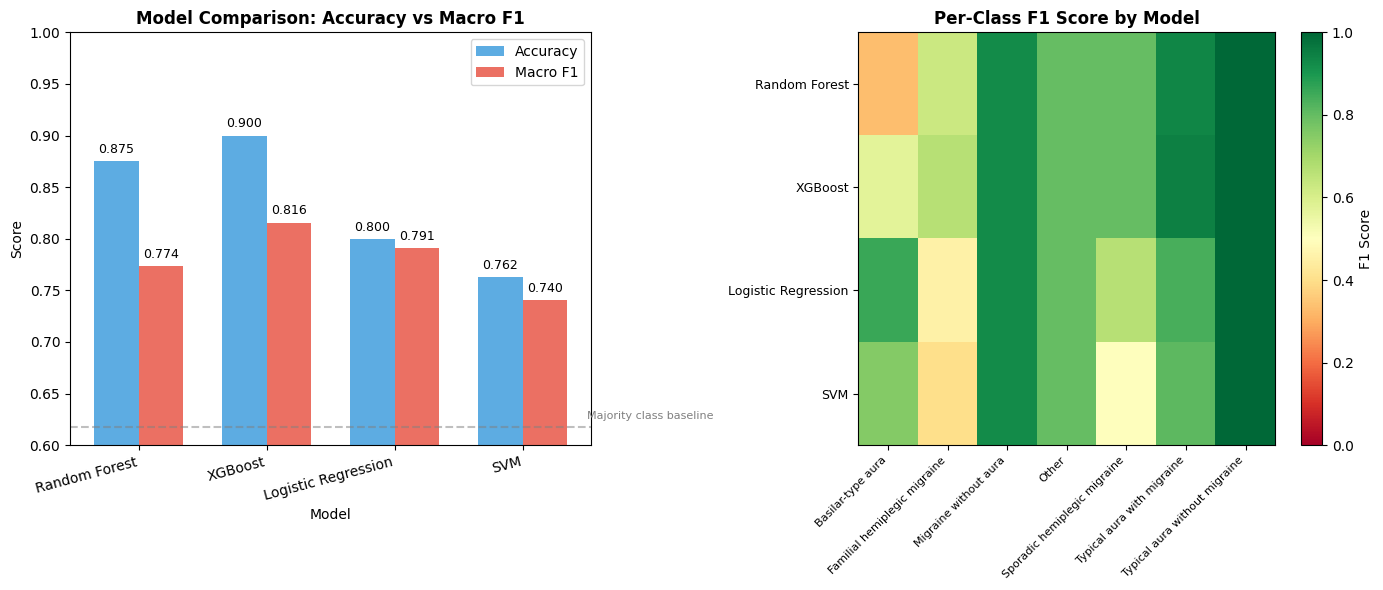

In [9]:
# Comparison data
models = ['Random Forest', 'XGBoost', 'Logistic Regression', 'SVM']
accuracies = [
    report_dict['accuracy'],
    report_xgb['accuracy'],
    report_lr['accuracy'],
    report_svm['accuracy']
]
macro_f1s = [
    report_dict['macro avg']['f1-score'],
    report_xgb['macro avg']['f1-score'],
    report_lr['macro avg']['f1-score'],
    report_svm['macro avg']['f1-score']
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: grouped bar chart
x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, accuracies, width,
                     label='Accuracy', color='#3498db', alpha=0.8)
bars2 = axes[0].bar(x + width/2, macro_f1s, width,
                     label='Macro F1', color='#e74c3c', alpha=0.8)

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison: Accuracy vs Macro F1', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim(0.6, 1.0)
axes[0].axhline(y=0.6175, color='gray', linestyle='--', alpha=0.5)
axes[0].text(3.5, 0.625, 'Majority class baseline', fontsize=8, color='gray')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# Right: per-class F1 heatmap
class_f1s = {}
for model_name, report in zip(models, [report_dict, report_xgb, report_lr, report_svm]):
    class_f1s[model_name] = [report[cls]['f1-score'] for cls in le.classes_]

f1_matrix = np.array(list(class_f1s.values()))

im = axes[1].imshow(f1_matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_xticks(range(len(le.classes_)))
axes[1].set_xticklabels(le.classes_, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks(range(len(models)))
axes[1].set_yticklabels(models, fontsize=9)
axes[1].set_title('Per-Class F1 Score by Model', fontweight='bold')
plt.colorbar(im, ax=axes[1], label='F1 Score')

plt.tight_layout()
plt.savefig('figures/accuracy_f1.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import scipy.stats as stats

print("REPEATED STRATIFIED CROSS-VALIDATION")
print("5 folds × 20 repeats = 100 evaluations per model")
print("=" * 60)

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)

# Random Forest
rf_cv = RandomForestClassifier(
    n_estimators=200, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_scores = cross_val_score(rf_cv, X, y_encoded,
                             cv=rskf, scoring='f1_macro', n_jobs=-1)

# XGBoost
xgb_cv = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
xgb_scores = cross_val_score(xgb_cv, X, y_encoded,
                              cv=rskf, scoring='f1_macro', n_jobs=-1)

# Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=42, solver='lbfgs'
    ))
])
lr_scores = cross_val_score(lr_pipeline, X, y_encoded,
                             cv=rskf, scoring='f1_macro', n_jobs=-1)

# SVM pipeline
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(
        kernel='rbf', class_weight='balanced',
        random_state=42, probability=True
    ))
])
svm_scores = cross_val_score(svm_pipeline, X, y_encoded,
                              cv=rskf, scoring='f1_macro', n_jobs=-1)

def confidence_interval_95(scores):
    """
    Compute 95% confidence interval using t-distribution.
    Appropriate for small-to-medium sample sizes.
    """
    n = len(scores)
    mean = scores.mean()
    se = stats.sem(scores)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    return mean, scores.std(), ci[0], ci[1]

print(f"\n{'Model':<22} {'Mean':>7} {'Std':>7} {'95% CI':>20} {'n_eval':>7}")
print("-" * 65)

all_scores = [
    ('Random Forest', rf_scores),
    ('XGBoost', xgb_scores),
    ('Logistic Regression', lr_scores),
    ('SVM', svm_scores)
]

for name, scores in all_scores:
    mean, std, ci_low, ci_high = confidence_interval_95(scores)
    ci_str = f"[{ci_low:.3f}, {ci_high:.3f}]"
    print(f"{name:<22} {mean:>7.4f} {std:>7.4f} {ci_str:>20} {len(scores):>7}")

best_idx = np.argmax([s.mean() for _, s in all_scores])
print(f"\nBest model: {all_scores[best_idx][0]}")
print(f"Mean Macro F1: {all_scores[best_idx][1].mean():.4f} "
      f"± {all_scores[best_idx][1].std():.4f}")

REPEATED STRATIFIED CROSS-VALIDATION
5 folds × 20 repeats = 100 evaluations per model

Model                     Mean     Std               95% CI  n_eval
-----------------------------------------------------------------
Random Forest           0.7672  0.0636       [0.754, 0.780]     100
XGBoost                 0.7240  0.0733       [0.709, 0.739]     100
Logistic Regression     0.7868  0.0476       [0.777, 0.796]     100
SVM                     0.7898  0.0635       [0.777, 0.802]     100

Best model: SVM
Mean Macro F1: 0.7898 ± 0.0635


In [11]:
print("OVERFITTING CHECK — Train vs Test Performance")
print("=" * 55)
print(f"{'Model':<25} {'Train Macro F1':>15} {'Test Macro F1':>15} {'Gap':>8}")
print("-" * 55)

# Random Forest — predict on training data
y_train_pred_rf = rf_model.predict(X_train)
train_f1_rf = classification_report(y_train, y_train_pred_rf,
                                     output_dict=True, zero_division=0)['macro avg']['f1-score']

# XGBoost
y_train_pred_xgb = xgb_model.predict(X_train)
train_f1_xgb = classification_report(y_train, y_train_pred_xgb,
                                      output_dict=True, zero_division=0)['macro avg']['f1-score']

# Logistic Regression — uses scaled data
y_train_pred_lr = lr_model.predict(X_train_scaled)
train_f1_lr = classification_report(y_train, y_train_pred_lr,
                                     output_dict=True, zero_division=0)['macro avg']['f1-score']

# SVM
y_train_pred_svm = svm_model.predict(X_train_scaled)
train_f1_svm = classification_report(y_train, y_train_pred_svm,
                                      output_dict=True, zero_division=0)['macro avg']['f1-score']

results = [
    ('Random Forest', train_f1_rf, macro_f1s[0]),
    ('XGBoost', train_f1_xgb, macro_f1s[1]),
    ('Logistic Regression', train_f1_lr, macro_f1s[2]),
    ('SVM', train_f1_svm, macro_f1s[3])
]

for model_name, train_f1, test_f1 in results:
    gap = train_f1 - test_f1
    flag = " ← OVERFIT" if gap > 0.15 else ""
    print(f"{model_name:<25} {train_f1:>15.4f} {test_f1:>15.4f} {gap:>8.4f}{flag}")

OVERFITTING CHECK — Train vs Test Performance
Model                      Train Macro F1   Test Macro F1      Gap
-------------------------------------------------------
Random Forest                      0.9656          0.7739   0.1917 ← OVERFIT
XGBoost                            0.9784          0.8157   0.1627 ← OVERFIT
Logistic Regression                0.8700          0.7912   0.0788
SVM                                0.8911          0.7404   0.1507 ← OVERFIT


SHAP array shape: (80, 23, 7)
Interpreting as: (80 patients, 23 features, 7 classes)


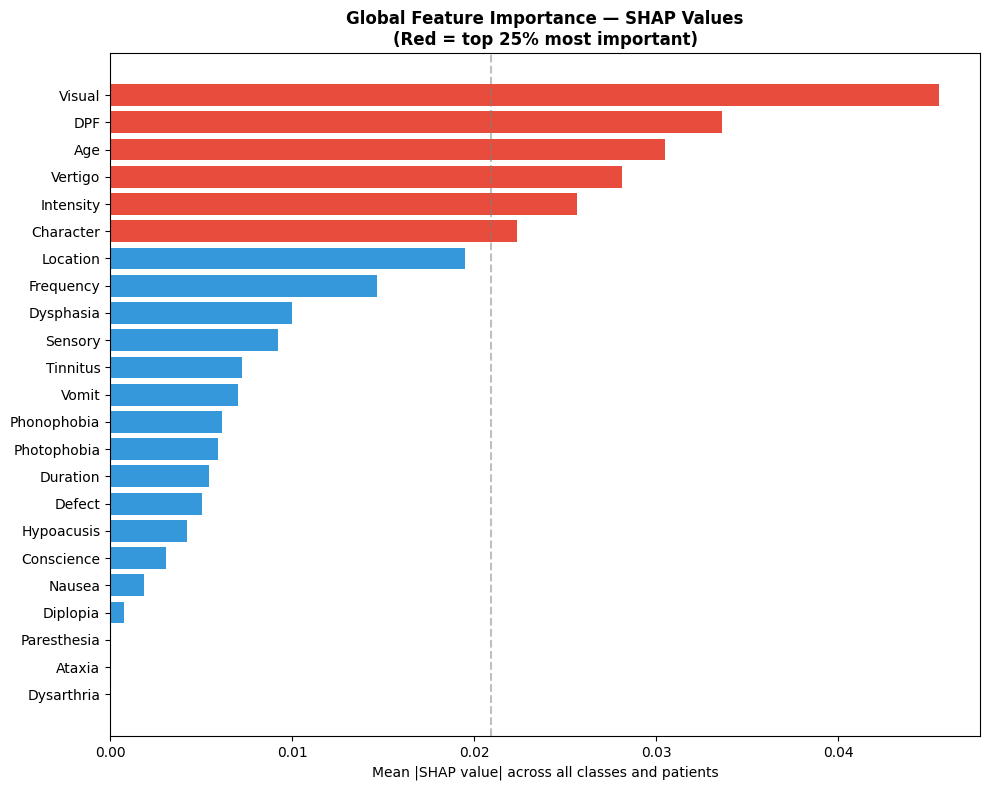

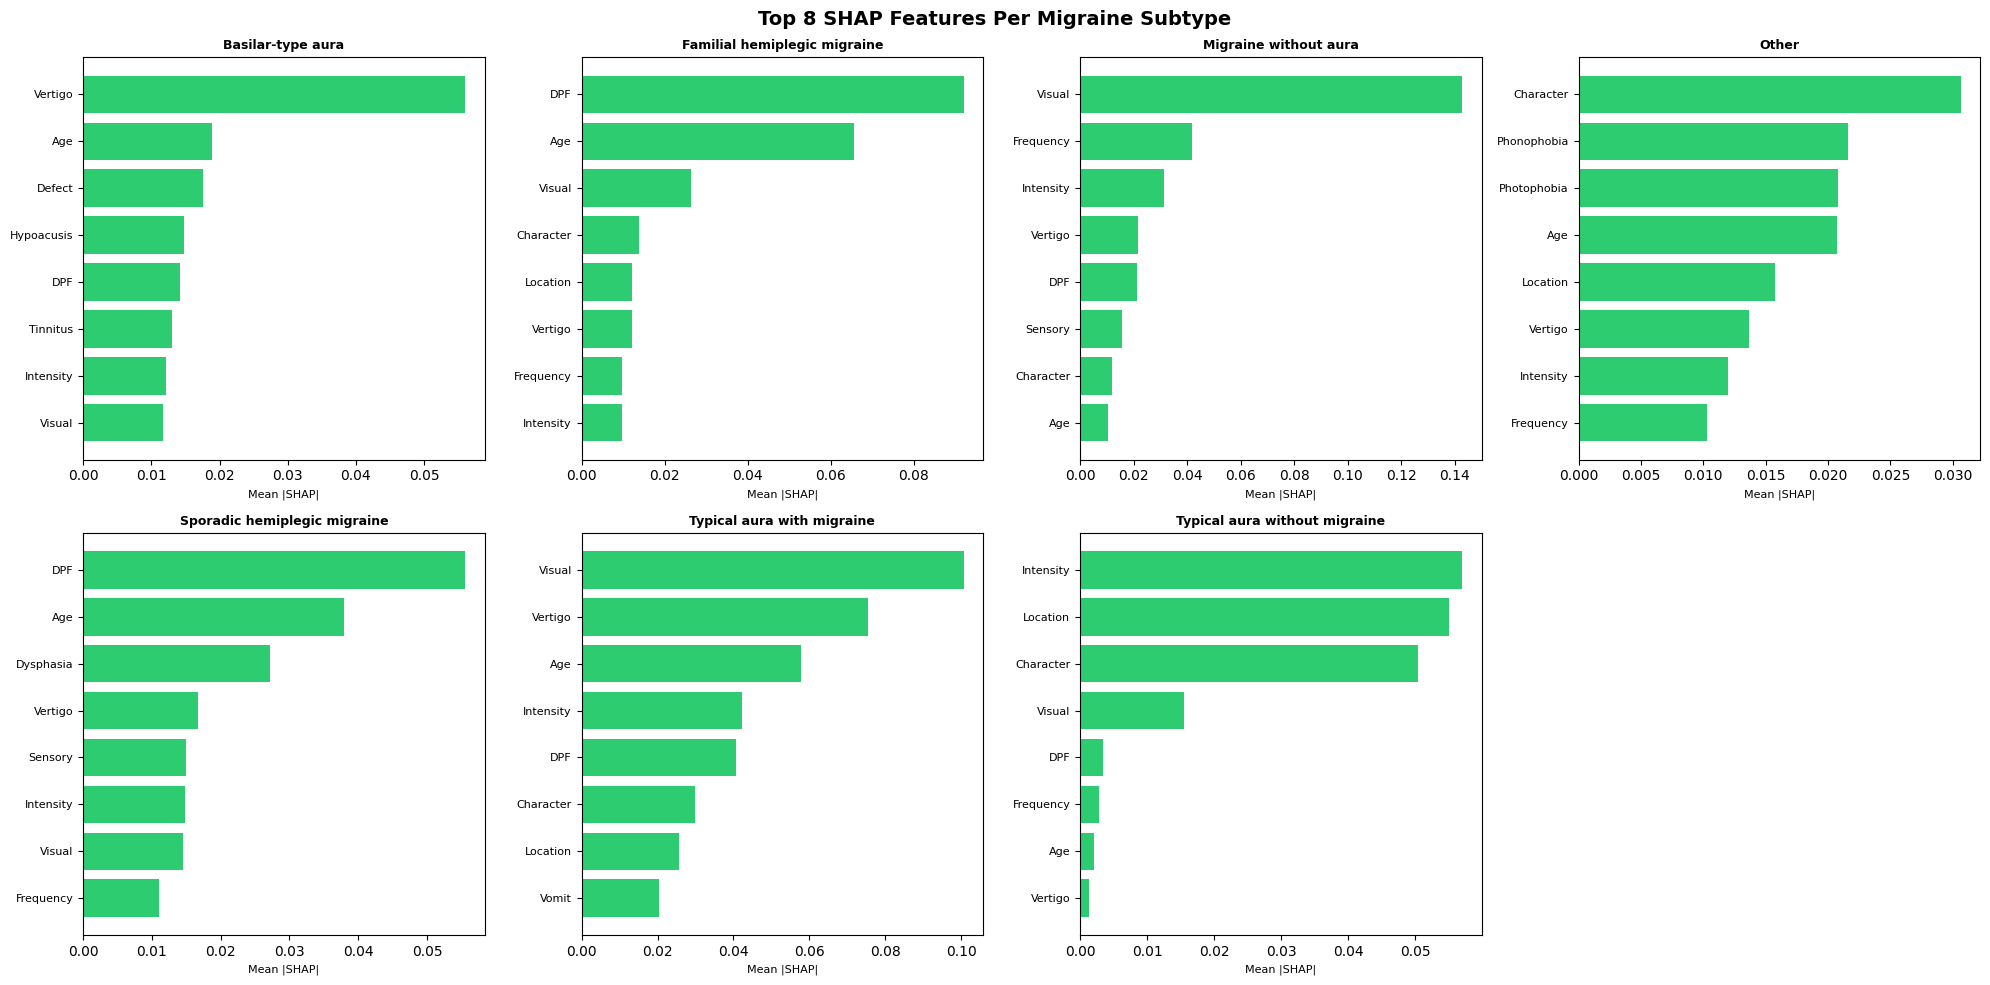

In [12]:
import shap
shap.initjs()

# Build explainer on trained RF model
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Handle new SHAP format (80, 23, 7)
shap_array = np.array(shap_values)
print(f"SHAP array shape: {shap_array.shape}")
print(f"Interpreting as: ({shap_array.shape[0]} patients, "
      f"{shap_array.shape[1]} features, "
      f"{shap_array.shape[2]} classes)")

feature_names = X_test.columns.tolist()

# Global importance — average absolute SHAP across all patients and classes
# axis=0 averages across patients, axis=2 averages across classes

shap_importance = np.abs(shap_array).mean(axis=0).mean(axis=1)

# Global importance plot
sorted_idx = np.argsort(shap_importance)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if imp > np.percentile(shap_importance, 75)
          else '#3498db' for imp in shap_importance[sorted_idx]]

ax.barh(range(len(feature_names)),
        shap_importance[sorted_idx],
        color=colors)
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=10)
ax.set_xlabel('Mean |SHAP value| across all classes and patients')
ax.set_title('Global Feature Importance — SHAP Values\n(Red = top 25% most important)',
             fontweight='bold')
ax.axvline(x=np.percentile(shap_importance, 75),
           color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('figures/global_shap.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class importance plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for class_idx, class_name in enumerate(le.classes_):
    # New format: select class using last axis
    class_shap = shap_array[:, :, class_idx]  # shape (80, 23)
    mean_abs_shap = np.abs(class_shap).mean(axis=0)  # shape (23,)
    top_idx = np.argsort(mean_abs_shap)[-8:]

    axes[class_idx].barh(
        range(8),
        mean_abs_shap[top_idx],
        color='#2ecc71'
    )
    axes[class_idx].set_yticks(range(8))
    axes[class_idx].set_yticklabels(
        [feature_names[i] for i in top_idx], fontsize=8
    )
    axes[class_idx].set_title(f'{class_name}', fontsize=9, fontweight='bold')
    axes[class_idx].set_xlabel('Mean |SHAP|', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Top 8 SHAP Features Per Migraine Subtype',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/all_subtypes.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print(f"Type of shap_values: {type(shap_values)}")
print(f"Length: {len(shap_values)}")
print(f"Shape of first element: {np.array(shap_values[0]).shape}")

# If it's a 3D array
shap_array = np.array(shap_values)
print(f"Full array shape: {shap_array.shape}")

Type of shap_values: <class 'numpy.ndarray'>
Length: 80
Shape of first element: (23, 7)
Full array shape: (80, 23, 7)


In [14]:
# ── Knowledge Base ──────────────────────────────────────────
MIGRAINE_KNOWLEDGE = {
    "Typical aura with migraine": {
        "description": "Visual, sensory or speech aura followed by headache.",
        "genetic_associations": ["KCNK18 (TRESK potassium channel)",
                                  "variants near CACNA1A"],
        "heritability": "40-60% — strong familial clustering",
        "key_symptoms": ["Visual aura", "Unilateral throbbing headache",
                         "Photophobia", "Phonophobia", "Nausea"],
        "clinical_recommendation": "Discuss aura characterisation with neurologist. "
                                    "Preventive therapy if attacks frequent. Avoid "
                                    "oestrogen-containing contraceptives due to stroke risk.",
        "red_flags": "Aura lasting >60 minutes or motor symptoms warrant urgent evaluation."
    },
    "Migraine without aura": {
        "description": "Recurrent headache without preceding neurological symptoms.",
        "genetic_associations": ["Multiple loci — highly polygenic", "TRPM8", "LRP1"],
        "heritability": "40-50% — moderate familial clustering",
        "key_symptoms": ["Unilateral throbbing headache", "Nausea/vomiting",
                         "Photophobia", "Phonophobia"],
        "clinical_recommendation": "Triptans effective for acute attacks. Preventive "
                                    "therapy if >4 attacks/month.",
        "red_flags": "Sudden onset severe headache requires urgent evaluation."
    },
    "Familial hemiplegic migraine": {
        "description": "Rare migraine with motor aura — temporary weakness on one side.",
        "genetic_associations": ["CACNA1A (calcium channel)",
                                  "ATP1A2 (sodium-potassium pump)",
                                  "SCN1A (sodium channel)"],
        "heritability": "Near-Mendelian in some families — autosomal dominant possible",
        "key_symptoms": ["Hemiplegia during aura", "Visual aura",
                         "Speech disturbance", "Strong family history"],
        "clinical_recommendation": "Genetic testing for CACNA1A, ATP1A2, SCN1A recommended. "
                                    "Avoid triptans. Neurologist referral essential.",
        "red_flags": "Motor symptoms during aura always require neurological evaluation."
    },
    "Basilar-type aura": {
        "description": "Aura symptoms from brainstem — vertigo, diplopia, altered consciousness.",
        "genetic_associations": ["Overlaps with FHM genetics", "CACNA1A variants"],
        "heritability": "Moderate familial clustering",
        "key_symptoms": ["Vertigo", "Diplopia", "Dysarthria",
                         "Tinnitus", "Altered consciousness"],
        "clinical_recommendation": "Avoid triptans. Neurologist referral recommended. "
                                    "MRI to exclude posterior fossa pathology.",
        "red_flags": "Brainstem symptoms can mimic stroke — urgent evaluation if first episode."
    },
    "Typical aura without migraine": {
        "description": "Aura symptoms without subsequent headache.",
        "genetic_associations": ["Shares genetics with Typical aura with migraine"],
        "heritability": "Moderate — often co-occurs in same families as aura migraine",
        "key_symptoms": ["Visual aura", "Sensory aura", "No significant headache"],
        "clinical_recommendation": "Neurological assessment at first presentation. "
                                    "May not require treatment.",
        "red_flags": "New onset aura without headache after age 40 requires TIA exclusion."
    },
    "Sporadic hemiplegic migraine": {
        "description": "Same as FHM clinically but without family history.",
        "genetic_associations": ["CACNA1A, ATP1A2, SCN1A — same as FHM",
                                  "May represent de novo mutations"],
        "heritability": "No family history by definition",
        "key_symptoms": ["Hemiplegia during aura", "Visual aura", "No family history"],
        "clinical_recommendation": "Genetic testing recommended. Avoid triptans. "
                                    "Neurologist referral essential.",
        "red_flags": "Motor aura always requires neurological evaluation."
    },
    "Other": {
        "description": "Presentations not fitting standard ICHD-3 classifications.",
        "genetic_associations": ["Heterogeneous"],
        "heritability": "Variable",
        "key_symptoms": ["Variable"],
        "clinical_recommendation": "Specialist headache clinic referral recommended.",
        "red_flags": "Significant change in headache pattern warrants clinical evaluation."
    }
}

# ── Core Functions ───────────────────────────────────────────

def get_symptom_profile(age, duration, frequency, location,
                         character, intensity, nausea, vomit,
                         phonophobia, photophobia, visual, sensory,
                         dysphasia, dysarthria, vertigo, tinnitus,
                         hypoacusis, diplopia, defect, ataxia,
                         conscience, paresthesia, dpf):
    return pd.DataFrame([[
        age, duration, frequency, location, character, intensity,
        nausea, vomit, phonophobia, photophobia, visual, sensory,
        dysphasia, dysarthria, vertigo, tinnitus, hypoacusis,
        diplopia, defect, ataxia, conscience, paresthesia, dpf
    ]], columns=X_train.columns)


def is_dpf_driven(proba, profile):
    profile_no_dpf = profile.copy()
    profile_no_dpf['DPF'] = 0
    proba_no_dpf = rf_model.predict_proba(profile_no_dpf)[0]
    top_with = np.argmax(proba)
    top_without = np.argmax(proba_no_dpf)
    dpf_influence = abs(proba[top_with] - proba_no_dpf[top_with])
    return top_with != top_without, dpf_influence, proba_no_dpf


def analyse_family(members):
    results = []
    for member in members:
        name = member['name']
        profile = get_symptom_profile(
            **{k: v for k, v in member.items() if k != 'name'}
        )
        proba = rf_model.predict_proba(profile)[0]
        pred_changed, dpf_influence, proba_no_dpf = is_dpf_driven(proba, profile)
        ranked = sorted(enumerate(proba), key=lambda x: x[1], reverse=True)
        results.append({
            'name': name,
            'profile': profile,
            'proba': proba,
            'proba_no_dpf': proba_no_dpf,
            'dpf_changed_prediction': pred_changed,
            'dpf_influence': dpf_influence,
            'ranked_subtypes': ranked
        })
    return results


def compute_family_concordance(results):
    if len(results) < 2:
        return 1.0, []
    probas = np.array([r['proba'] for r in results])
    names = [r['name'] for r in results]
    concordance_scores = []
    for i in range(len(probas)):
        for j in range(i+1, len(probas)):
            corr = np.corrcoef(probas[i], probas[j])[0, 1]
            concordance_scores.append((names[i], names[j], corr))
    mean_concordance = np.mean([c[2] for c in concordance_scores])
    return mean_concordance, concordance_scores


def print_family_report(results, concordance_score, concordance_details):
    print("=" * 65)
    print("MIGRAINE MAP — FAMILY PATTERN ANALYSIS REPORT")
    print("=" * 65)

    for r in results:
        print(f"\n{'─' * 65}")
        print(f"FAMILY MEMBER: {r['name'].upper()}")
        print(f"{'─' * 65}")
        print("\nSubtype Probability Distribution:")
        for class_idx, prob in r['ranked_subtypes']:
            bar = '█' * int(prob * 40)
            print(f"  {le.classes_[class_idx]:<35} {prob:.3f}  {bar}")

        top_idx = r['ranked_subtypes'][0][0]
        top_name = le.classes_[top_idx]
        top_prob = r['ranked_subtypes'][0][1]
        print(f"\nPrimary classification: {top_name} ({top_prob:.1%})")

        if r['dpf_changed_prediction']:
            alt_name = le.classes_[np.argmax(r['proba_no_dpf'])]
            alt_prob = np.max(r['proba_no_dpf'])
            print(f"\n⚠  DPF FLAG: Family history is driving this classification.")
            print(f"   Symptom-only prediction: {alt_name} ({alt_prob:.1%})")
            print(f"   Symptom-based result may be more clinically relevant.")
        elif r['dpf_influence'] > 0.1:
            print(f"\n⚠  DPF NOTE: Family history contributed "
                  f"{r['dpf_influence']:.1%} to prediction confidence.")
        else:
            print(f"\n✓  Symptom-driven classification.")

        if top_name in MIGRAINE_KNOWLEDGE:
            kb = MIGRAINE_KNOWLEDGE[top_name]
            print(f"\nClinical Profile: {kb['description']}")
            print(f"Genetic Associations: {', '.join(kb['genetic_associations'])}")
            print(f"Heritability: {kb['heritability']}")
            print(f"Recommendation: {kb['clinical_recommendation']}")
            print(f"Red Flags: {kb['red_flags']}")

    print(f"\n{'=' * 65}")
    print("FAMILY CONCORDANCE")
    print(f"{'=' * 65}")
    print(f"Mean concordance: {concordance_score:.3f}")
    if concordance_score > 0.8:
        print("Interpretation: HIGH — very similar subtype profiles across family")
    elif concordance_score > 0.5:
        print("Interpretation: MODERATE — shared patterns with individual variation")
    else:
        print("Interpretation: LOW — divergent profiles, possibly different subtypes")
    for name_a, name_b, score in concordance_details:
        print(f"  {name_a} ↔ {name_b}: {score:.3f}")

    print(f"\n{'=' * 65}")
    print("DISCLAIMER: Computational proof-of-concept only.")
    print("Not a clinical diagnosis. Consult a qualified neurologist.")
    print("=" * 65)

In [15]:
test_cases = [
    {
        'name': 'Case 1 — Typical Aura With Migraine',
        'age': 34, 'duration': 2, 'frequency': 3, 'location': 1,
        'character': 1, 'intensity': 3, 'nausea': 1, 'vomit': 0,
        'phonophobia': 1, 'photophobia': 1, 'visual': 1, 'sensory': 1,
        'dysphasia': 0, 'dysarthria': 0, 'vertigo': 0, 'tinnitus': 0,
        'hypoacusis': 0, 'diplopia': 0, 'defect': 0, 'ataxia': 0,
        'conscience': 0, 'paresthesia': 0, 'dpf': 1
    },
    {
        'name': 'Case 2 — Migraine Without Aura',
        'age': 42, 'duration': 2, 'frequency': 2, 'location': 1,
        'character': 1, 'intensity': 3, 'nausea': 1, 'vomit': 1,
        'phonophobia': 1, 'photophobia': 1, 'visual': 0, 'sensory': 0,
        'dysphasia': 0, 'dysarthria': 0, 'vertigo': 0, 'tinnitus': 0,
        'hypoacusis': 0, 'diplopia': 0, 'defect': 0, 'ataxia': 0,
        'conscience': 0, 'paresthesia': 0, 'dpf': 0
    },
    {
        'name': 'Case 3 — Familial Hemiplegic Migraine',
        'age': 22, 'duration': 2, 'frequency': 2, 'location': 1,
        'character': 1, 'intensity': 3, 'nausea': 1, 'vomit': 0,
        'phonophobia': 1, 'photophobia': 1, 'visual': 1, 'sensory': 1,
        'dysphasia': 0, 'dysarthria': 1, 'vertigo': 0, 'tinnitus': 0,
        'hypoacusis': 0, 'diplopia': 0, 'defect': 1, 'ataxia': 0,
        'conscience': 0, 'paresthesia': 1, 'dpf': 1
    },
    {
        'name': 'Case 4 — Basilar-Type Aura',
        'age': 28, 'duration': 1, 'frequency': 2, 'location': 2,
        'character': 1, 'intensity': 2, 'nausea': 1, 'vomit': 1,
        'phonophobia': 0, 'photophobia': 1, 'visual': 1, 'sensory': 0,
        'dysphasia': 0, 'dysarthria': 1, 'vertigo': 1, 'tinnitus': 1,
        'hypoacusis': 1, 'diplopia': 1, 'defect': 0, 'ataxia': 1,
        'conscience': 1, 'paresthesia': 0, 'dpf': 0
    },
    {
        'name': 'Case 5 — Typical Aura Without Migraine',
        'age': 39, 'duration': 1, 'frequency': 1, 'location': 1,
        'character': 1, 'intensity': 1, 'nausea': 0, 'vomit': 0,
        'phonophobia': 0, 'photophobia': 0, 'visual': 1, 'sensory': 1,
        'dysphasia': 1, 'dysarthria': 0, 'vertigo': 0, 'tinnitus': 0,
        'hypoacusis': 0, 'diplopia': 0, 'defect': 0, 'ataxia': 0,
        'conscience': 0, 'paresthesia': 0, 'dpf': 1
    },
    {
        'name': 'Case 6 — Sporadic Hemiplegic Migraine',
        'age': 25, 'duration': 2, 'frequency': 2, 'location': 1,
        'character': 1, 'intensity': 3, 'nausea': 1, 'vomit': 0,
        'phonophobia': 1, 'photophobia': 1, 'visual': 1, 'sensory': 1,
        'dysphasia': 0, 'dysarthria': 1, 'vertigo': 0, 'tinnitus': 0,
        'hypoacusis': 0, 'diplopia': 0, 'defect': 1, 'ataxia': 0,
        'conscience': 0, 'paresthesia': 1, 'dpf': 0
    },
    {
        'name': 'Case 7 — Other',
        'age': 51, 'duration': 1, 'frequency': 4, 'location': 2,
        'character': 2, 'intensity': 2, 'nausea': 0, 'vomit': 0,
        'phonophobia': 1, 'photophobia': 1, 'visual': 0, 'sensory': 0,
        'dysphasia': 0, 'dysarthria': 0, 'vertigo': 0, 'tinnitus': 0,
        'hypoacusis': 0, 'diplopia': 0, 'defect': 0, 'ataxia': 0,
        'conscience': 0, 'paresthesia': 0, 'dpf': 0
    }
]

# Run analysis
results = analyse_family(test_cases)
concordance_score, concordance_details = compute_family_concordance(results)
print_family_report(results, concordance_score, concordance_details)

MIGRAINE MAP — FAMILY PATTERN ANALYSIS REPORT

─────────────────────────────────────────────────────────────────
FAMILY MEMBER: CASE 1 — TYPICAL AURA WITH MIGRAINE
─────────────────────────────────────────────────────────────────

Subtype Probability Distribution:
  Typical aura with migraine          0.664  ██████████████████████████
  Familial hemiplegic migraine        0.137  █████
  Basilar-type aura                   0.078  ███
  Other                               0.045  █
  Migraine without aura               0.039  █
  Sporadic hemiplegic migraine        0.031  █
  Typical aura without migraine       0.006  

Primary classification: Typical aura with migraine (66.4%)

✓  Symptom-driven classification.

Clinical Profile: Visual, sensory or speech aura followed by headache.
Genetic Associations: KCNK18 (TRESK potassium channel), variants near CACNA1A
Heritability: 40-60% — strong familial clustering
Recommendation: Discuss aura characterisation with neurologist. Preventive therap

In [16]:
print("PER-CLASS ANALYSIS SUMMARY")
print("=" * 55)

class_f1_data = {}
for cls in le.classes_:
    class_f1_data[cls] = report_xgb[cls]['f1-score']

best_class = max(class_f1_data, key=class_f1_data.get)
worst_class = min(class_f1_data, key=class_f1_data.get)

print(f"\nBest classified subtype:")
print(f"  {best_class}: F1 = {class_f1_data[best_class]:.3f}")
print(f"  Likely reason: {'Distinct symptom profile' if best_class == 'Typical aura without migraine' else 'Large training sample and distinct feature pattern'}")

print(f"\nWorst classified subtype:")
print(f"  {worst_class}: F1 = {class_f1_data[worst_class]:.3f}")
print(f"  Likely reason: Insufficient training samples ({pd.Series(y_train).value_counts().sort_index()[le.transform([worst_class])[0]]} training examples)")

# Most confused pair from confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
np.fill_diagonal(cm, 0)
max_confusion_idx = np.unravel_index(cm.argmax(), cm.shape)
confused_true = le.classes_[max_confusion_idx[0]]
confused_pred = le.classes_[max_confusion_idx[1]]
confusion_count = cm[max_confusion_idx]

print(f"\nMost confused subtype pair:")
print(f"  True: {confused_true}")
print(f"  Predicted as: {confused_pred}")
print(f"  Occurrences: {confusion_count} times in test set")
print(f"  Clinical explanation: Overlapping symptom profiles —")
print(f"  both subtypes share aura features; distinction requires")
print(f"  detailed motor symptom assessment.")

print(f"\nClinical implication:")
print(f"  Rare subtypes with <20 training samples showed F1 below 0.70.")
print(f"  Performance is data-limited, not model-limited.")
print(f"  Doubling minority class samples would likely improve")
print(f"  classification more than any architectural change.")

PER-CLASS ANALYSIS SUMMARY

Best classified subtype:
  Typical aura without migraine: F1 = 1.000
  Likely reason: Distinct symptom profile

Worst classified subtype:
  Basilar-type aura: F1 = 0.571
  Likely reason: Insufficient training samples (14 training examples)

Most confused subtype pair:
  True: Basilar-type aura
  Predicted as: Familial hemiplegic migraine
  Occurrences: 2 times in test set
  Clinical explanation: Overlapping symptom profiles —
  both subtypes share aura features; distinction requires
  detailed motor symptom assessment.

Clinical implication:
  Rare subtypes with <20 training samples showed F1 below 0.70.
  Performance is data-limited, not model-limited.
  Doubling minority class samples would likely improve
  classification more than any architectural change.


In [17]:
family_members = [
    {
        'name': 'Sister',
        'age': 18,
        'duration': 2,
        'frequency': 4,
        'location': 1,
        'character': 1,
        'intensity': 2,
        'nausea': 1,
        'vomit': 0,
        'phonophobia': 1,
        'photophobia': 1,
        'visual': 0,
        'sensory': 0,
        'dysphasia': 1,
        'dysarthria': 0,
        'vertigo': 1,
        'tinnitus': 1,
        'hypoacusis': 0,
        'diplopia': 0,
        'defect': 0,
        'ataxia': 0,
        'conscience': 1,
        'paresthesia': 1,
        'dpf': 1
    },
    {
        'name': 'Mother',
        'age': 47,
        'duration': 2,
        'frequency': 2,
        'location': 1,
        'character': 1,
        'intensity': 3,
        'nausea': 1,
        'vomit': 1,
        'phonophobia': 1,
        'photophobia': 1,
        'visual': 0,
        'sensory': 0,
        'dysphasia': 1,
        'dysarthria': 0,
        'vertigo': 0,
        'tinnitus': 0,
        'hypoacusis': 0,
        'diplopia': 0,
        'defect': 0,
        'ataxia': 0,
        'conscience': 1,
        'paresthesia': 0,
        'dpf': 1
    },
    {
        'name': 'Grandmother',
        'age': 70,
        'duration': 2,
        'frequency': 2,
        'location': 1,
        'character': 1,
        'intensity': 2,
        'nausea': 1,
        'vomit': 0,
        'phonophobia': 1,
        'photophobia': 1,
        'visual': 0,
        'sensory': 0,
        'dysphasia': 0,
        'dysarthria': 0,
        'vertigo': 0,
        'tinnitus': 0,
        'hypoacusis': 0,
        'diplopia': 0,
        'defect': 0,
        'ataxia': 0,
        'conscience': 0,
        'paresthesia': 0,
        'dpf': 0
    },
    {
        'name': 'Anusha',
        'age': 20,
        'duration': 2,
        'frequency': 4,
        'location': 2,
        'character': 1,
        'intensity': 2,
        'nausea': 1,
        'vomit': 1,
        'phonophobia': 0,
        'photophobia': 1,
        'visual': 0,
        'sensory': 0,
        'dysphasia': 0,
        'dysarthria': 0,
        'vertigo': 1,
        'tinnitus': 0,
        'hypoacusis': 0,
        'diplopia': 0,
        'defect': 0,
        'ataxia': 0,
        'conscience': 1,
        'paresthesia': 0,
        'dpf': 1
    }
]

results = analyse_family(family_members)
concordance_score, concordance_details = compute_family_concordance(results)
print_family_report(results, concordance_score, concordance_details)

MIGRAINE MAP — FAMILY PATTERN ANALYSIS REPORT

─────────────────────────────────────────────────────────────────
FAMILY MEMBER: SISTER
─────────────────────────────────────────────────────────────────

Subtype Probability Distribution:
  Familial hemiplegic migraine        0.410  ████████████████
  Sporadic hemiplegic migraine        0.197  ███████
  Migraine without aura               0.197  ███████
  Basilar-type aura                   0.089  ███
  Typical aura with migraine          0.055  ██
  Other                               0.044  █
  Typical aura without migraine       0.008  

Primary classification: Familial hemiplegic migraine (41.0%)

⚠  DPF FLAG: Family history is driving this classification.
   Symptom-only prediction: Sporadic hemiplegic migraine (33.3%)
   Symptom-based result may be more clinically relevant.

Clinical Profile: Rare migraine with motor aura — temporary weakness on one side.
Genetic Associations: CACNA1A (calcium channel), ATP1A2 (sodium-potassium pump